# Analysis

## Setup

In [ ]:
import json, calendar
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from fastcore.utils import *

In [ ]:
DOWNSAMPLE_COHORTS = False
EXCLUDE_SHORT_LIVED = False

## Data Collection

This query aggregates monthly package creation and release data from PyPI's public BigQuery dataset, which we use to plot overall package growth over time (Chart 1). Run it in [BigQuery console](https://console.cloud.google.com/bigquery) and export results to `bquxjob_*.csv`:

In [ ]:

monthly_df = pd.read_csv('bquxjob_3bd11968_19ba66fbefa.csv')
monthly_df.head()

,month,version_releases,new_packages
0,2005-03-01 00:00:00.000000 UTC,4,4
1,2005-04-01 00:00:00.000000 UTC,6,5
2,2005-05-01 00:00:00.000000 UTC,5,2
3,2005-06-01 00:00:00.000000 UTC,5,2
4,2005-07-01 00:00:00.000000 UTC,13,7


Download the list of top PyPI packages by download count. We use this to filter to "real" actively-used packages:

In [ ]:
existing = sorted(Path('.').glob('top-pypi-packages-downloaded-*.csv'))
if existing: pkgs_df = pd.read_csv(existing[-1])
else: pkgs_df = pd.read_csv("https://hugovk.github.io/top-pypi-packages/top-pypi-packages.csv"); pkgs_df.to_csv(f"top-pypi-packages-downloaded-{datetime.now():%Y%m%d}.csv", index=False)
pkgs_df.head()

,download_count,project
0,1438455634,boto3
1,1106102051,urllib3
2,1010375477,botocore
3,990302186,typing-extensions
4,959087169,requests


Scrape PyPI API for release metadata of top 1500 packages (skip if already cached):

In [ ]:
import httpx, time

cache_dir = Path("pypi_cache")
cache_dir.mkdir(exist_ok=True)
top1500 = pkgs_df.head(1500)['project'].tolist()

for pkg in top1500:
    cache_file = cache_dir / f"{pkg}.json"
    if cache_file.exists(): continue
    resp = httpx.get(f"https://pypi.org/pypi/{pkg}/json")
    if resp.status_code == 200: cache_file.write_text(json.dumps(resp.json())); print(f"✓ {pkg}")
    else: print(f"✗ {pkg}: {resp.status_code}")
    time.sleep(0.1)
print(f"\nDone! Cached {len(list(cache_dir.glob('*.json')))} packages")


Done! Cached 1500 packages


Extract releases from cached JSON into `releases.csv`:

In [ ]:
if not Path('releases.csv').exists():
    rows = []
    for f in cache_dir.glob("*.json"):
        data = f.read_json()
        pkg = data['info']['name']
        for version, files in data['releases'].items():
            if files: rows.append(dict(project=pkg, release=version, upload_time=files[0]['upload_time_iso_8601']))
    releases_df = pd.DataFrame(rows)
    releases_df.to_csv('releases.csv', index=False)
    print(f"Saved {len(releases_df)} releases from {releases_df['project'].nunique()} packages")
else: releases_df = pd.read_csv('releases.csv')
releases_df.head()

,project,release,upload_time
0,storage3,0.1.0,2021-12-25T15:23:42.051165Z
1,storage3,0.1.1,2021-12-25T15:46:45.925233Z
2,storage3,0.10.0,2024-11-22T16:25:51.419458Z
3,storage3,0.11.0,2024-12-30T12:35:02.199781Z
4,storage3,0.11.1,2025-01-23T22:57:19.823770Z


Classify packages as AI-related using OpenAI batch API. First extract descriptions:

In [ ]:
def get_desc(f):
    info = json.loads(f.read_text())['info']
    return dict(project=info['name'], summary=info.get('summary') or '')
descs = pd.DataFrame([get_desc(f) for f in cache_dir.glob("*.json")])
descs.head()

,project,summary
0,requests-oauthlib,OAuthlib authentication support for Requests.
1,curl-cffi,"libcurl ffi bindings for Python, with imperson..."
2,realtime,
3,blobfile,"Read GCS, ABS and local paths with the same in..."
4,docstring-parser,"Parse Python docstrings in reST, Google and Nu..."


Create and submit batch classification job (commented out - only run if `classify_results.jsonl` doesn't exist):

In [ ]:
# from openai import OpenAI
# client = OpenAI()

# requests = []
# for _, row in descs.iterrows():
#     requests.append(dict(custom_id=row['project'], method="POST", url="/v1/chat/completions",
#         body=dict(model="gpt-5.2", max_completion_tokens=5, messages=[
#             dict(role="system", content="Classify if this Python package is AI-related (machine learning, LLMs, neural networks, AI infrastructure, deep learning, GPUs, etc). Reply with just 'True' or 'False'."),
#             dict(role="user", content=f"{row['project']}: {row['summary']}")])))

# Path("classify_requests.jsonl").write_text('\n'.join(json.dumps(r) for r in requests))
# batch_file = client.files.create(file=open("classify_requests.jsonl", "rb"), purpose="batch")
# batch_job = client.batches.create(input_file_id=batch_file.id, endpoint="/v1/chat/completions", completion_window="24h")
# print(f"Batch job: {batch_job.id}, Status: {batch_job.status}")

Check batch status and download results:

In [ ]:
# status = client.batches.retrieve(batch_job.id)
# print(f"Status: {status.status}, Completed: {status.request_counts.completed}/{status.request_counts.total}")
# if status.output_file_id:
#     Path("classify_results.jsonl").write_text(client.files.content(status.output_file_id).text)
#     print(f"Downloaded results")

In [ ]:
classifications = {(r := json.loads(line))['custom_id']: r['response']['body']['choices'][0]['message']['content'].strip().lower() == 'true' for line in Path("classify_results.jsonl").read_text().splitlines()}

Define cohort assignment based on first release date, and prep the releases dataframe with parsed timestamps and cohort labels:

In [ ]:
def cohort(dt):
    if dt.year >= 2023: return '3. Post-ChatGPT (2023+)'
    elif dt.year >= 2020: return '2. Pre-ChatGPT AI era (2020-22)'
    else: return '1. Pre-AI (before 2020)'
    
releases_df = releases_df[~releases_df['upload_time'].str.startswith('2026')]
releases_df['upload_time'] = pd.to_datetime(releases_df['upload_time'], format='ISO8601')
releases_df['first_release'] = pd.to_datetime(releases_df.groupby('project')['upload_time'].transform('min'))
releases_df['cohort'] = releases_df['first_release'].apply(cohort)
releases_df['year'] = releases_df['upload_time'].dt.year

Calculate annualized release counts per package-year, adjusting for partial years when a package was created mid-year:

In [ ]:
def annualize(grp):
    year = grp.name[1]
    first = max(grp['first_release'].iloc[0], pd.Timestamp(f'{year}-01-01', tz='UTC'))
    last = pd.Timestamp(f'{year}-12-31', tz='UTC')
    days_active = (last - first).days + 1
    fraction = days_active / (365 + calendar.isleap(year))
    return len(grp) / fraction if fraction > 0 else 0

annual = releases_df.groupby(['project', 'year', 'cohort']).apply(annualize, include_groups=False).reset_index(name='annualized_releases')

Merge AI classifications with annual release data and set up cohort color scheme for charts:

In [ ]:
descs['is_ai'] = descs['project'].map(classifications)
annual_classified = annual.merge(descs[['project', 'is_ai']], on='project')
data = annual_classified[annual_classified['year'] >= 2018]

In [ ]:
len(data)

8261

In [ ]:
if EXCLUDE_SHORT_LIVED:
    months_active = releases_df.groupby('project')['upload_time'].apply(lambda x: (x.max() - x.min()).days / 30)
    data = data[data['project'].isin(months_active[months_active > 2].index)]

if DOWNSAMPLE_COHORTS:
    pkg_cohort = data[['project', 'cohort']].drop_duplicates().merge(pkgs_df[['project', 'download_count']])
    min_size = pkg_cohort.groupby('cohort').size().min()
    top_pkgs = pkg_cohort.groupby('cohort').apply(lambda g: g.nlargest(min_size, 'download_count')['project']).reset_index(drop=True)
    data = data[data['project'].isin(top_pkgs)]

In [ ]:
filtered_projects = set(data['project'].unique())
print(f"Total packages in data: {len(filtered_projects)}")
print(f"DOWNSAMPLE_COHORTS={DOWNSAMPLE_COHORTS}, EXCLUDE_SHORT_LIVED={EXCLUDE_SHORT_LIVED}")

Total packages in data: 1484
DOWNSAMPLE_COHORTS=False, EXCLUDE_SHORT_LIVED=False


In [ ]:
data.groupby('cohort')['project'].nunique()

cohort
1. Pre-AI (before 2020)            1040
2. Pre-ChatGPT AI era (2020-22)     300
3. Post-ChatGPT (2023+)             144
Name: project, dtype: int64

In [ ]:
len(data)

8261

## Chart creation

In [ ]:
pub_style = {'figure.facecolor': 'white', 'axes.facecolor': 'white', 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.linewidth': 0.8, 'axes.labelsize': 11, 'axes.titlesize': 12, 'axes.titleweight': 'medium', 'xtick.labelsize': 9,
    'ytick.labelsize': 9, 'xtick.direction': 'out', 'ytick.direction': 'out', 'lines.linewidth': 1.5, 'legend.frameon': False,
    'legend.fontsize': 9, 'font.size': 10}
cohort_colors = {'1. Pre-AI (before 2020)': '#2c3e50', '2. Pre-ChatGPT AI era (2020-22)': '#e67e22', '3. Post-ChatGPT (2023+)': '#27ae60'}
plt.rcParams.update(pub_style)

def savefig(name): plt.savefig(name, dpi=150, bbox_inches='tight', facecolor='white')

def plot_cohort_bars(ax, data, colors, ylabel='Median Releases/Year', title=''):
    medians = data.groupby(['year', 'cohort'])['annualized_releases'].median().unstack()
    years, width, x = medians.index.values, 0.25, np.arange(len(medians.index))
    for i, cohort in enumerate(colors.keys()):
        if cohort in medians.columns: ax.bar(x + i*width, medians[cohort].fillna(0), width, color=colors[cohort], label=cohort.split('. ')[1])
    ax.set_ylabel(ylabel)
    ax.set_xticks(x + width)
    ax.set_xticklabels(years)
    if title: ax.set_title(title, loc='left', fontweight='bold')



### Chart 1: Package creation over time

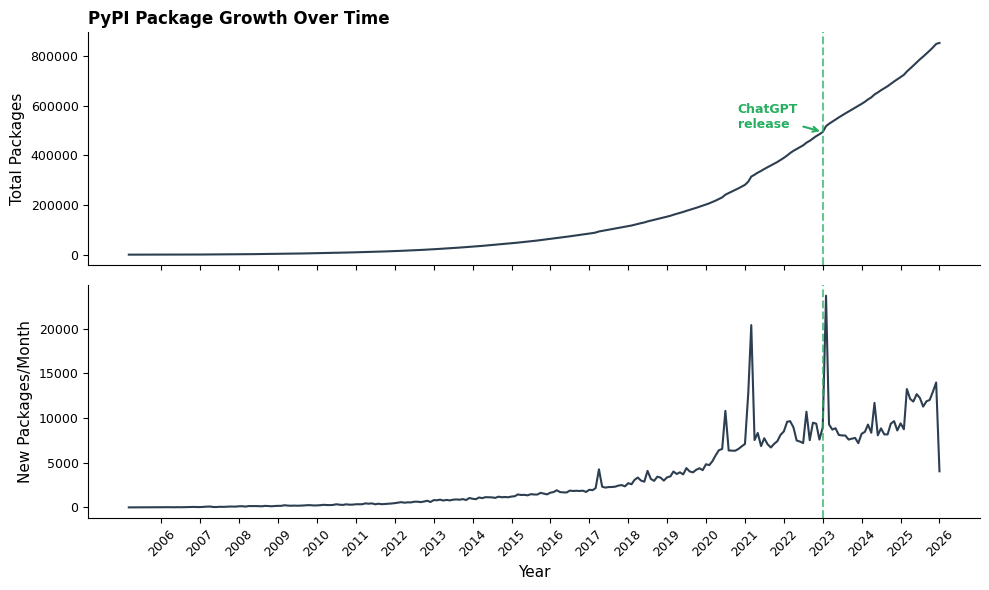

In [ ]:
monthly_df['month'] = pd.to_datetime(monthly_df['month'].str.replace(' UTC', ''))
monthly_df = monthly_df.sort_values('month')
monthly_df['total_packages'] = monthly_df['new_packages'].cumsum()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
ax1.plot(monthly_df['month'], monthly_df['total_packages'], color='#2c3e50', lw=1.5)
ax1.set_ylabel('Total Packages')
ax1.set_title('PyPI Package Growth Over Time', loc='left', fontweight='bold')

ax2.plot(monthly_df['month'], monthly_df['new_packages'], color='#2c3e50', lw=1.5)
ax2.set_ylabel('New Packages/Month')
ax2.set_xlabel('Year')

years = pd.date_range(start='2006-01-01', end='2026-01-01', freq='YS')
ax2.set_xticks(years)
ax2.set_xticklabels([y.year for y in years], rotation=45)

chatgpt_date = pd.Timestamp('2023-01-01')
for ax in [ax1, ax2]: ax.axvline(chatgpt_date, color='#27ae60', linestyle='--', lw=1.5, alpha=0.7)

ax1.annotate('ChatGPT\nrelease', xy=(chatgpt_date, monthly_df.loc[monthly_df['month'] <= chatgpt_date, 'total_packages'].iloc[-1]),
             xytext=(chatgpt_date - pd.Timedelta(days=800), monthly_df['total_packages'].max() * 0.6),
             fontsize=9, color='#27ae60', fontweight='bold', arrowprops=dict(arrowstyle='->', color='#27ae60', lw=1.5))

plt.tight_layout()
savefig('./so-where-are-all-the-ai-apps/chart_01_pypi_package_creation.png')

### Chart 2: Overall release frequency

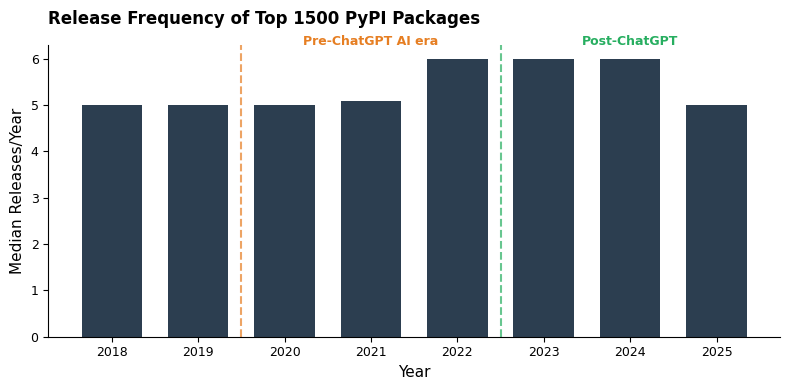

In [ ]:
overall_median = annual[(annual['year'] >= 2018) & (annual['year'] <= 2025) & (annual['project'].isin(filtered_projects))].groupby('year')['annualized_releases'].median()

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(overall_median.index, overall_median.values, color='#2c3e50', width=0.7)
ax.axvline(x=2019.5, color='#e67e22', linestyle='--', lw=1.5, alpha=0.7)
ax.axvline(x=2022.5, color='#27ae60', linestyle='--', lw=1.5, alpha=0.7)
ax.text(2021, 6.3, 'Pre-ChatGPT AI era', fontsize=9, fontweight='bold', color='#e67e22', ha='center')
ax.text(2024, 6.3, 'Post-ChatGPT', fontsize=9, fontweight='bold', color='#27ae60', ha='center')
ax.set_ylabel('Median Releases/Year')
ax.set_xlabel('Year')
ax.set_title('Release Frequency of Top 1500 PyPI Packages', loc='left', fontweight='bold', pad=15)

plt.tight_layout()
savefig('./so-where-are-all-the-ai-apps/chart_02_release_frequency_simple.png')

### Chart 3: Release frequency by cohort

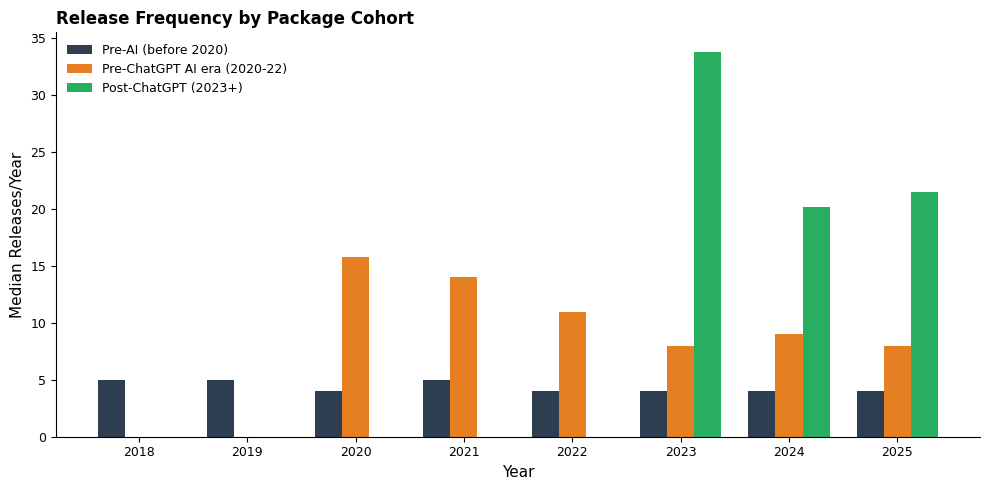

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
plot_cohort_bars(ax, data, cohort_colors, title='Release Frequency by Package Cohort')
ax.set_xlabel('Year')
ax.legend(loc='upper left', frameon=False)
plt.tight_layout()
savefig('./so-where-are-all-the-ai-apps/chart_03_release_frequency_cohort.png')

### Chart 4: Cohort vs secular effect

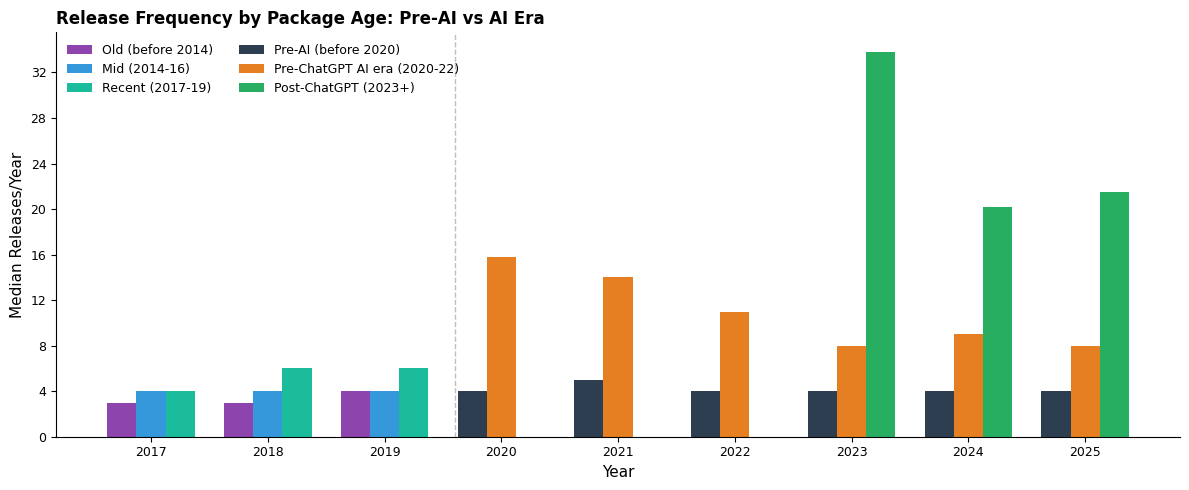

In [ ]:
def historical_cohort(dt):
    if dt.year >= 2017: return '3. Recent (2017-19)'
    elif dt.year >= 2014: return '2. Mid (2014-16)'
    else: return '1. Old (before 2014)'

pre_ai = releases_df[(releases_df['year'].between(2017, 2019)) & (releases_df['project'].isin(filtered_projects))].copy()
pre_ai['hist_cohort'] = pre_ai['first_release'].apply(historical_cohort)
hist_annual = pre_ai.groupby(['project', 'year', 'hist_cohort']).size().reset_index(name='releases')
hist_medians = hist_annual.groupby(['year', 'hist_cohort'])['releases'].median().unstack()

hist_colors = {'1. Old (before 2014)': '#8e44ad', '2. Mid (2014-16)': '#3498db', '3. Recent (2017-19)': '#1abc9c'}
curr_medians = data.groupby(['year', 'cohort'])['annualized_releases'].median().unstack()
curr_medians_filtered = curr_medians[curr_medians.index >= 2020]

fig, ax = plt.subplots(figsize=(12, 5))
all_years, width = list(range(2017, 2026)), 0.25
x = np.arange(len(all_years))

for i, (cohort, color) in enumerate(hist_colors.items()):
    vals = [hist_medians.loc[y, cohort] if y in hist_medians.index and cohort in hist_medians.columns else 0 for y in range(2017, 2020)] + [0] * 6
    ax.bar(x + i*width, vals, width, color=color, label=cohort.split('. ')[1])

for i, (cohort, color) in enumerate(cohort_colors.items()):
    vals = [0] * 3 + [curr_medians_filtered.loc[y, cohort] if y in curr_medians_filtered.index and cohort in curr_medians_filtered.columns else 0 for y in range(2020, 2026)]
    ax.bar(x + i*width, vals, width, color=color, label=cohort.split('. ')[1])

ax.axvline(x=2.85, color='gray', linestyle='--', lw=1, alpha=0.5)
ax.set_ylabel('Median Releases/Year')
ax.set_xlabel('Year')
ax.set_title('Release Frequency by Package Age: Pre-AI vs AI Era', loc='left', fontweight='bold')
ax.set_xticks(x + width)
ax.set_xticklabels(all_years)
ax.legend(loc='upper left', frameon=False, ncol=2)
ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))
plt.tight_layout()
savefig('./so-where-are-all-the-ai-apps/chart_04_cohort_comparison.png')

### Chart 5: Release frequency by AI-related vs not

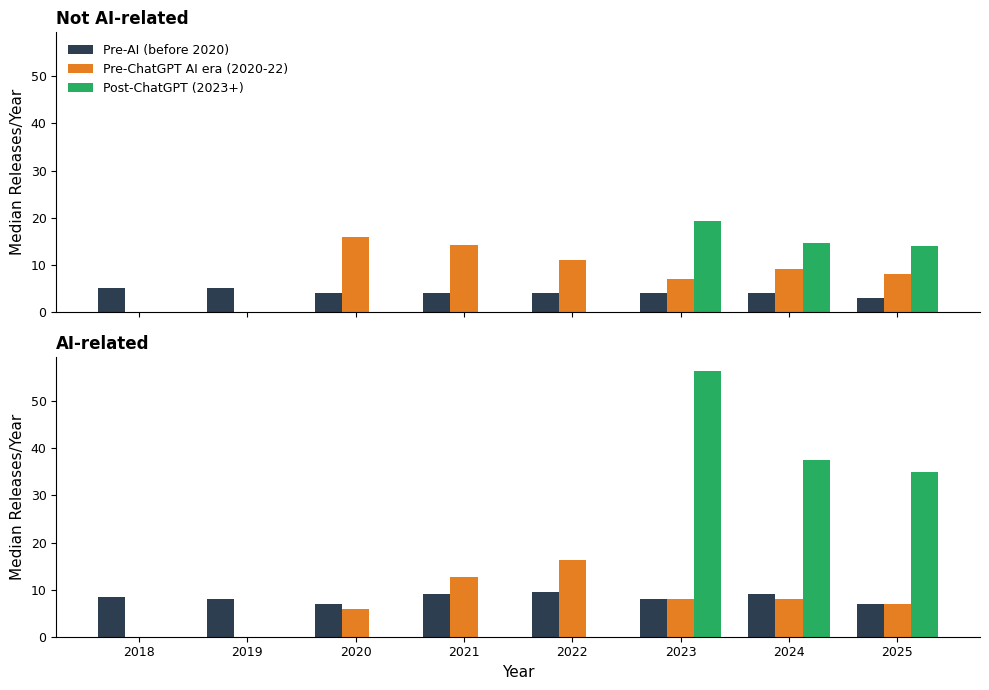

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True, sharey=True)
for ax, (is_ai, label) in zip(axes, [(False, 'Not AI-related'), (True, 'AI-related')]):
    plot_cohort_bars(ax, data[data['is_ai'] == is_ai], cohort_colors, title=label)
axes[0].legend(loc='upper left', frameon=False)
axes[1].set_xlabel('Year')
plt.tight_layout()
savefig('./so-where-are-all-the-ai-apps/chart_05_release_frequency_by_ai.png')

# Blog

Fans of vibecoding and agentic tools say they are 2x as productive, 10x as productive – maybe 100x as productive! Last month, someone [built an entire web browser from scratch](https://cursor.com/blog/scaling-agents). Amazing!

So, skeptics reasonably ask, where are all the apps? If AI users are becoming (let's be conservative) merely 2x more productive, then where do we look to see 2x more software being produced?

Let's check the data. We'll look at PyPI, the central repository for Python packages, and look at how that number has grown over time.

## Counting packages


There it is, see it? The release of ChatGPT. Does it look like an epochal revolution of software productivity on the upper chart? No.

There *are* a few spikes in the lower chart showing new packages/month, in what you might call the "AI era" of 2020 onward. But those reflect spam and malware floods, not genuine package creation.[^1]

![Two-panel chart showing PyPI total packages growing exponentially to 800k and new packages per month fluctuating around 5-15k, with ChatGPT release marked showing no obvious inflection point](./so-where-are-all-the-ai-apps/chart_01_pypi_package_creation.png)

## Counting updates

But, you might say, package creation is not the right measure. Anyone can create a "package" which is nothing but a hello world and upload it to PyPI. This is always easier to do than creating something durable which people use. So we want to look at "real" packages, packages which are actually downloaded and, presumably, updated over time.

So let's consider a different chart. We'll start by filtering to the 1,500 most downloaded Python packages on PyPI[^2], so that we can be sure we are considering real libraries in actual use. Then we'll plot the median annual release frequency[^3] over time.

![Bar chart showing median releases per year for top 1500 PyPI packages staying flat around 5-6 from 2018-2025](./so-where-are-all-the-ai-apps/chart_02_release_frequency_simple.png)

Hmm. That's also not too dramatic. In 2022, the median release frequency went from 5 to 6, and then back down to 5 in 2025, when the models were stronger than ever.

## Slicing by age

But maybe we're not looking deeply enough? Let's take the set of all our most downloaded packages, and divide it into three cohorts depending on their first release — that is, depending on when they were born. We'll have the pre-AI packages, the pre-ChatGPT packages, and finally the post-ChatGPT packages.[^4]

Maybe the benefits of AI are only really available when you are *starting* a project. This might plausibly be the case if AI works better when starting from a blank slate. In this case, we'd expect to see the AI effect only in the second two cohorts, the "AI native" packages.

![Grouped bar chart showing release frequency by package birth cohort, with post-ChatGPT packages reaching 35 releases/year vs 5 for pre-AI packages](./so-where-are-all-the-ai-apps/chart_03_release_frequency_cohort.png)

And there it is! Or at least, there's _something_. There has been at least a ~3x increase in the median release frequency for packages born since the advent of ChatGPT, reaching as high as 35 releases/year in 2023, which is 7x higher than the pre-AI cohort.

## Controlling for youth

But is this simply because young packages always naturally get updated more frequently? 
Let's check by also splitting the Pre-AI era into multiple cohorts.

![Bar chart comparing pre-AI era (2017-19) cohorts with AI era (2020-25) non-AI packages, showing young packages always update more but effect is much stronger in AI era](./so-where-are-all-the-ai-apps/chart_04_cohort_comparison.png)

The left side shows the pre-AI era and, indeed, packages which were young at that time were updated more frequently than their elders in that group. But the effect was modest. The right side shows the AI era: the young-vs-old gap has widened dramatically. 

This is not just "normal young package behavior"; something additional is happening. But what's driving it?

## It's about AI

Let's split packages by whether they're _about_ AI or not, by classifying based on the package's description.[^5]

![Two-panel bar chart showing release frequency split by AI-related packages, with AI packages showing much higher update rates especially post-ChatGPT](./so-where-are-all-the-ai-apps/chart_05_release_frequency_by_ai.png)

This split reveals a lot! The packages which are *not* about AI look much more like the pre-AI era, in the relative increase in frequency of young vs old packages. That increase *is* still higher, but it's not mind-bending.

In contrast, it's the packages which *are* about AI which show the massive increase in release frequency. For example, they reached a median level of around 55 releases per year in 2023.[^6] This is an increase of more than 5x vs older packages in that year (or, a 175% AI boost off an assumed 100% youth boost).

In short, for some reason, newly created packages *about* AI are being updated *much* more frequently.

Of course the interesting question is, why?

## So what?

Before considering what's causing this, let's recap the evidence:

1. There is no obvious increase in the rate of package creation as a whole, and only a marginal increase in the rate of package updates as a whole. 

2. However, there is _some_ increase in the update frequency of packages which were created after AI, which are not about AI.

3. And there is a _huge_ increase in the update frequency of PyPI packages which were created after AI, and which are _about AI_.

As goes without saying this data is imperfect. But it still seems easy to say confidently what is _not_ happening, and to at least offer some reasonable interpretations about what is going on.[^7]

Here are three questions which target _why_ this might be happening.

1. **Is AI massively boosting developer productivity across the board?**

    No. We are not seeing indications that developers as a whole are 100x or even 10x more productive. The bumper crop of new packages, or new package updates, just does not exist! 
    
    Relax. You are not missing a party that literally everyone else was invited to.

2. **Are some developers building much faster, by using AI?**.

    Perhaps? But the visible aggregate effect is still so modest, that if some devs are getting this big boost, there certainly isn't many of them. Or else the purported boost is not really that big. What we see in aggregate is a no uptick in package update frequency.

    _However_, we do see a boost in newly-created packages, and super highly concentrated in newly-created packages _about AI_.

3. **Are people building an enormous amount of software _for using AI_?**

    Yes, yes they are. The huge jump in update frequency for recent packages about AI is really the headline effect here. This is the puzzle that needs to be explained. 

So, let's ask again, why? Why is this jump concentrated in software about AI? We do have two hypotheses:

**AI "skill issue"**. Maybe people building AI tools are also the ones most likely to know how to use AI effectively. This would produce an uneven effect on productivity, where people building AI tools also built faster. In fact, we build AI tools here at AnswerAI and our experience is that, yes, they do boost productivity. But sadly, this effect is not the crazy 30x jump one sees in the PyPi update frequencies, and the biggest effect depends on _also_ having solid expertise in software engineering. So we doubt that an "AI skill issue" explains most of the jump. 

**Money and hype 🤑💰**. An enormous amount of funding and enthusiasm has flowed into AI, and it is being converted into (amongst other things) PyPI packages. Maybe it's not that developers on these packages have gotten more productive. It's just that there are more of them, and they can work more hours, because there is more money to pay for that work. On this view, it’s not so much that AI is making developers superhuman, but that supercharged interest in AI is paying for a higher rate of creation and iteration *about* AI.

Alas, the data do not tell us which of these effects is larger.

But what we can say is that the main measurable impact of the generative AI revolution, so far, at least on the PyPi ecosystem, is not a Cambrian explosion in all software. But a sharp and concentrated burst in the updating of packages that are themselves part of the AI ecosystem.

[^1]: See the official pypi blog: [Inbound Malware Volume Report](https://blog.pypi.org/posts/2023-09-18-inbound-malware-reporting/)

[^2]: We used the top 1,500 packages by download count in the last month of 2025, as downloaded from [hugovk's monthly dump of 15,0000 top-pypi-packages](https://hugovk.github.io/top-pypi-packages/) January 19th 2026. The top 10% of that dataset covers 90% of all downloads.

[^3]: We annualized release frequency for a package's first active year. As a robustness check, to avoid inflating estimates for packages with short histories, we redid the analysis and excluded packages active for only 1-2 months, and saw similar patterns.

[^4]: As a robustness check, we downsampled older cohorts to match the size of recent cohorts, and saw similar patterns.

[^5]: We used an GPT5.2 to classify packages as "AI-related" or not based on their PyPI description. This is imperfect but directionally useful.

[^6]: This figure is robust to our methodological choices: downsampling older cohorts and excluding short-lived packages both preserve the pattern.

[^7]: All analysis code and data is available at [https://github.com/AnswerDotAI/pypi-analysis](https://github.com/AnswerDotAI/pypi-analysis).